In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
from forecasting_utils import FOCUS_AGES, clean_opossum_data, load_raw_data

# Opossum Arrivals EDA  

This notebook is the first pass through the raw intake data. I used it to get a feel for what was actually in the dataset, what looked messy, and what seemed worth modeling later.

Nothing too dramatic here, just me sanity-checking the data before building anything on top of it.


In [3]:
raw_df = load_raw_data()
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10536 entries, 0 to 10535
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Id              10534 non-null  str  
 1   Name            6515 non-null   str  
 2   Admission date  10522 non-null  str  
 3   Status          10522 non-null  str  
 4   Final date      10515 non-null  str  
 5   Age             10520 non-null  str  
 6   City            10376 non-null  str  
dtypes: str(7)
memory usage: 576.3 KB


In [4]:
raw_df.head()

,Id,Name,Admission date,Status,Final date,Age,City
0,2000-00008,NaN,1/5/2000,EOA,1/5/2000,A,Lisle
1,2000-00016,NaN,1/13/2000,RTW,1/13/2000,A,Glen Ellyn
2,2000-00034,NaN,1/24/2000,E,1/28/2000,A,Glendale Heights
3,2000-00045,NaN,2/3/2000,RTW,2/3/2000,A,Bolingbrook
4,2000-00046,NaN,2/4/2000,R,3/1/2000,A,Lombard


In [5]:
invalid_rows = raw_df.loc[
    ~raw_df["Id"].astype("string").str.fullmatch(r"^\d{4}-\d{5}$", na=False)
]
invalid_rows

,Id,Name,Admission date,Status,Final date,Age,City
4038,white fur,NaN,NaN,NaN,NaN,NaN,NaN
4176,Green head,NaN,NaN,NaN,NaN,NaN,NaN
4288,R Orange,NaN,NaN,NaN,NaN,NaN,NaN
4289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4378,R pink,NaN,NaN,NaN,NaN,NaN,NaN
4453,Orange Head,NaN,NaN,NaN,NaN,NaN,NaN
4605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4675,R purple,NaN,NaN,NaN,NaN,NaN,NaN
4677,+ green R ear,NaN,NaN,NaN,NaN,NaN,NaN
4760,Purple R ear,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = clean_opossum_data()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10522 entries, 0 to 10521
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              10522 non-null  str           
 1   name            6515 non-null   str           
 2   admission_date  10522 non-null  datetime64[us]
 3   status          10522 non-null  string        
 4   final_date      10515 non-null  datetime64[us]
 5   age_raw         10522 non-null  string        
 6   city            10522 non-null  string        
 7   age_group       10522 non-null  string        
 8   year            10522 non-null  int64         
 9   month           10522 non-null  int64         
 10  day             10522 non-null  int64         
 11  day_of_week     10522 non-null  str           
 12  week_of_year    10522 non-null  int64         
 13  days_in_care    10515 non-null  float64       
 14  is_focus_age    10522 non-null  bool          
dtypes: bool(1), d

In [7]:
df.head()

,id,name,admission_date,status,final_date,age_raw,city,age_group,year,month,day,day_of_week,week_of_year,days_in_care,is_focus_age
0,2000-00008,NaN,2000-01-05,EuthanizedAfterArrival,2000-01-05,A,Lisle,adult,2000,1,5,Wednesday,1,0.0,False
1,2000-00016,NaN,2000-01-13,ReturnToWild,2000-01-13,A,Glen Ellyn,adult,2000,1,13,Thursday,2,0.0,False
2,2000-00034,NaN,2000-01-24,Euthanized,2000-01-28,A,Glendale Heights,adult,2000,1,24,Monday,4,4.0,False
3,2000-00045,NaN,2000-02-03,ReturnToWild,2000-02-03,A,Bolingbrook,adult,2000,2,3,Thursday,5,0.0,False
4,2000-00046,NaN,2000-02-04,Released,2000-03-01,A,Lombard,adult,2000,2,4,Friday,5,26.0,False


### Focus on the juvenile and immature intake records

For arrival forecasting, this project is now centered on the subset of admissions whose raw age values map to:

- `juvenile`
- `immature`
- `young_of_year`
- `neonate`


In [8]:
age_counts_raw = df["age_raw"].value_counts(dropna=False)
age_counts_normalized = df["age_group"].value_counts(dropna=False)

print(age_counts_raw)
print(age_counts_normalized)

age_raw
J               4982
I               2784
A               1572
YoY              718
UNK              302
J (juvenile)      74
I (immature)      23
A (adult)         20
N                 19
L                 11
juvenille          7
H                  4
F                  4
                   2
Name: count, dtype: Int64
age_group
juvenile         5063
immature         2807
adult            1592
young_of_year     718
unknown           323
neonate            19
Name: count, dtype: Int64


In [9]:
focus_df = df.loc[df["is_focus_age"]].copy()
focus_df[["admission_date", "age_raw", "age_group", "city", "status"]].head()

,admission_date,age_raw,age_group,city,status
21,2000-04-01,I,immature,Lombard,EuthanizedAfterArrival
22,2000-04-01,I,immature,Lombard,EuthanizedAfterArrival
23,2000-04-01,I,immature,Lombard,EuthanizedAfterArrival
24,2000-04-01,I,immature,Lombard,EuthanizedAfterArrival
25,2000-04-01,I,immature,Lombard,EuthanizedAfterArrival


In [10]:
df.isna().sum().sort_values(ascending=False)

name              4007
final_date           7
days_in_care         7
admission_date       0
status               0
age_raw              0
id                   0
city                 0
age_group            0
month                0
year                 0
day                  0
day_of_week          0
week_of_year         0
is_focus_age         0
dtype: int64

In [11]:
summary = pd.DataFrame(
    {
        "rows": [len(df), len(focus_df)],
        "min_date": [df["admission_date"].min(), focus_df["admission_date"].min()],
        "max_date": [df["admission_date"].max(), focus_df["admission_date"].max()],
        "distinct_cities": [df["city"].nunique(), focus_df["city"].nunique()],
    },
    index=["all_records", "focus_age_records"],
)
summary

,rows,min_date,max_date,distinct_cities
all_records,10522,2000-01-05,2026-04-11,267
focus_age_records,8607,2000-04-01,2026-03-14,239


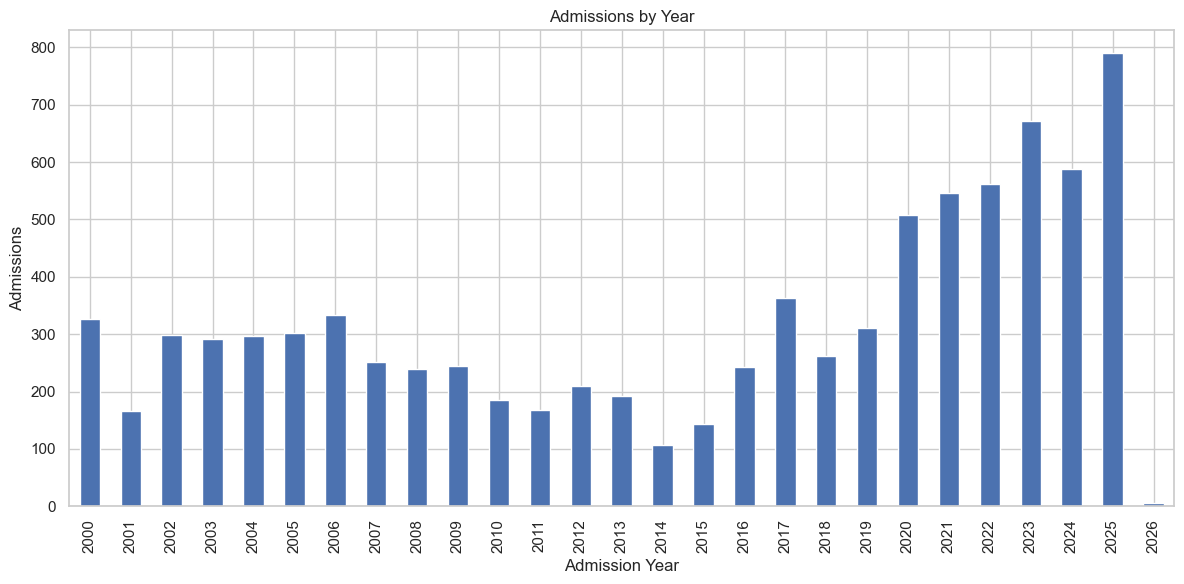

In [12]:
focus_df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Admissions by Year")
plt.xlabel("Admission Year")
plt.ylabel("Admissions")
plt.tight_layout()
plt.show()

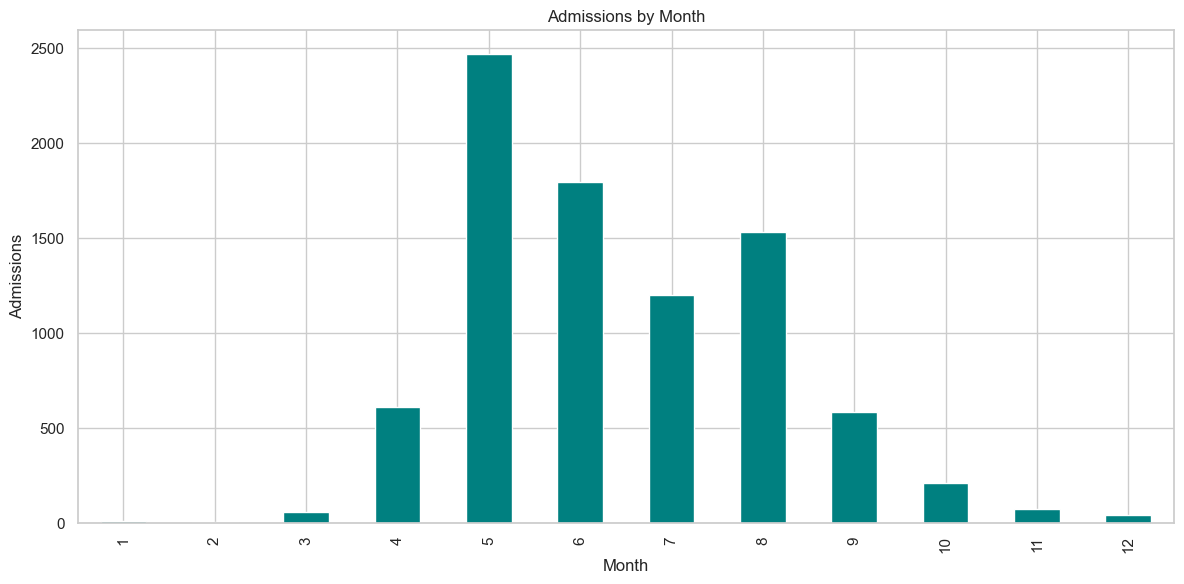

In [13]:
monthly_counts = focus_df.groupby("month").size()
monthly_counts.plot(kind="bar", color="teal")
plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.tight_layout()
plt.show()

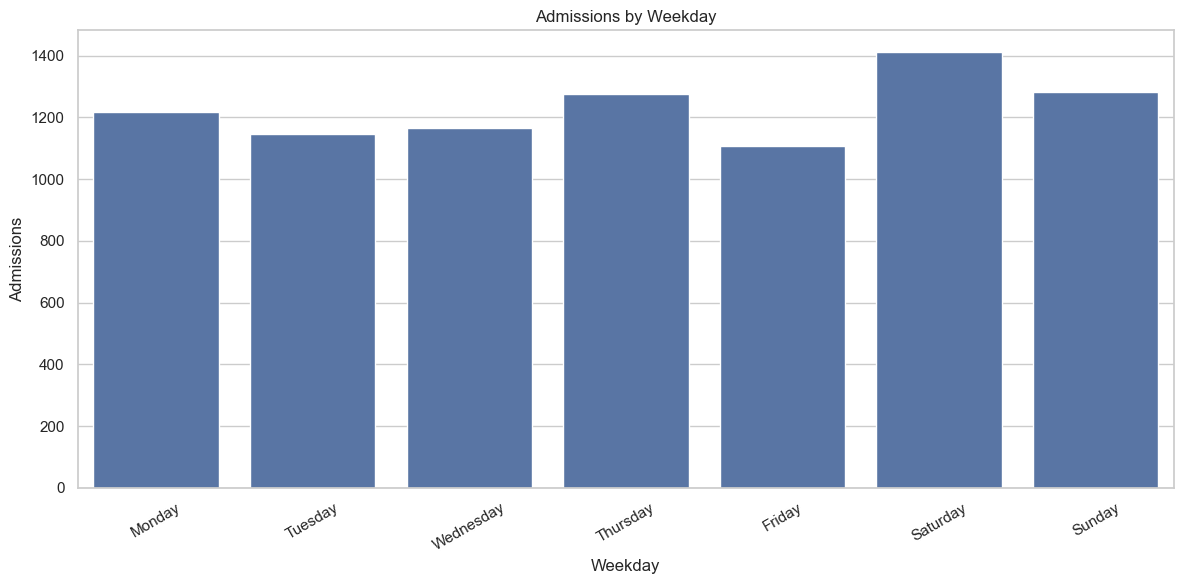

In [14]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=focus_df, x="day_of_week", order=weekday_order)
plt.title("Admissions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Admissions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

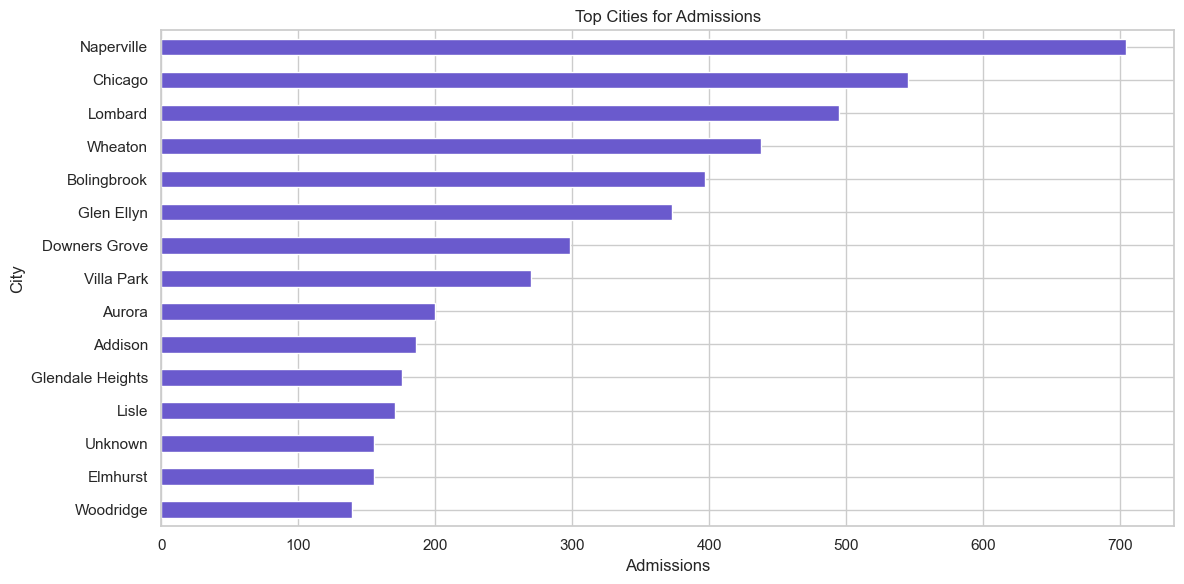

In [15]:
top_focus_cities = focus_df["city"].value_counts().head(15)
top_focus_cities.sort_values().plot(kind="barh", color="slateblue")
plt.title("Top Cities for Admissions")
plt.xlabel("Admissions")
plt.ylabel("City")
plt.tight_layout()
plt.show()

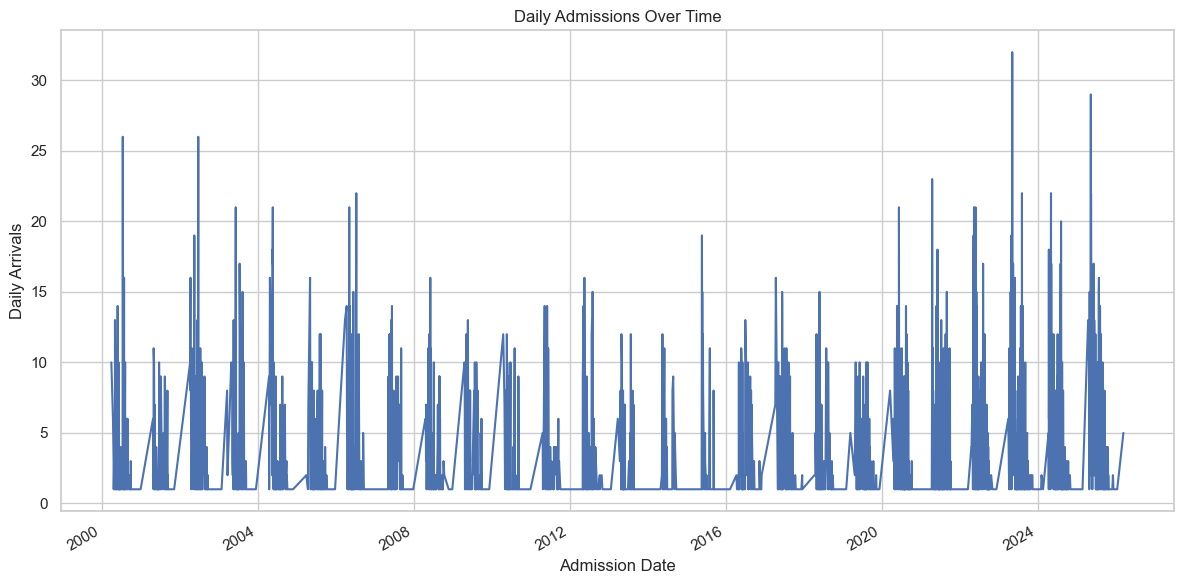

In [16]:
daily_focus = focus_df.groupby("admission_date").size().rename("arrivals")
daily_focus.plot()
plt.title("Daily Admissions Over Time")
plt.xlabel("Admission Date")
plt.ylabel("Daily Arrivals")
plt.tight_layout()
plt.show()

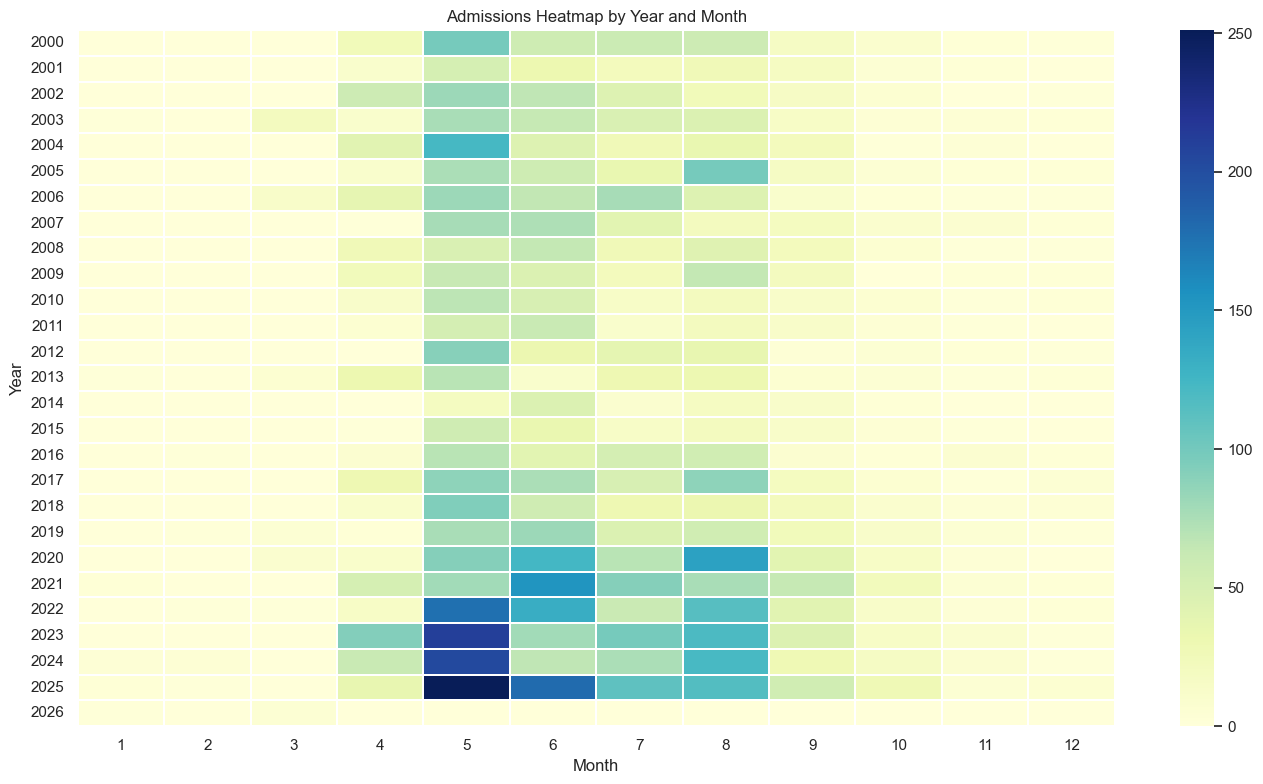

In [17]:
year_month = (
    focus_df.groupby(["year", "month"])
    .size()
    .rename("arrivals")
    .reset_index()
    .pivot(index="year", columns="month", values="arrivals")
    .fillna(0)
)

plt.figure(figsize=(14, 8))
sns.heatmap(year_month, cmap="YlGnBu", linewidths=0.2)
plt.title("Admissions Heatmap by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

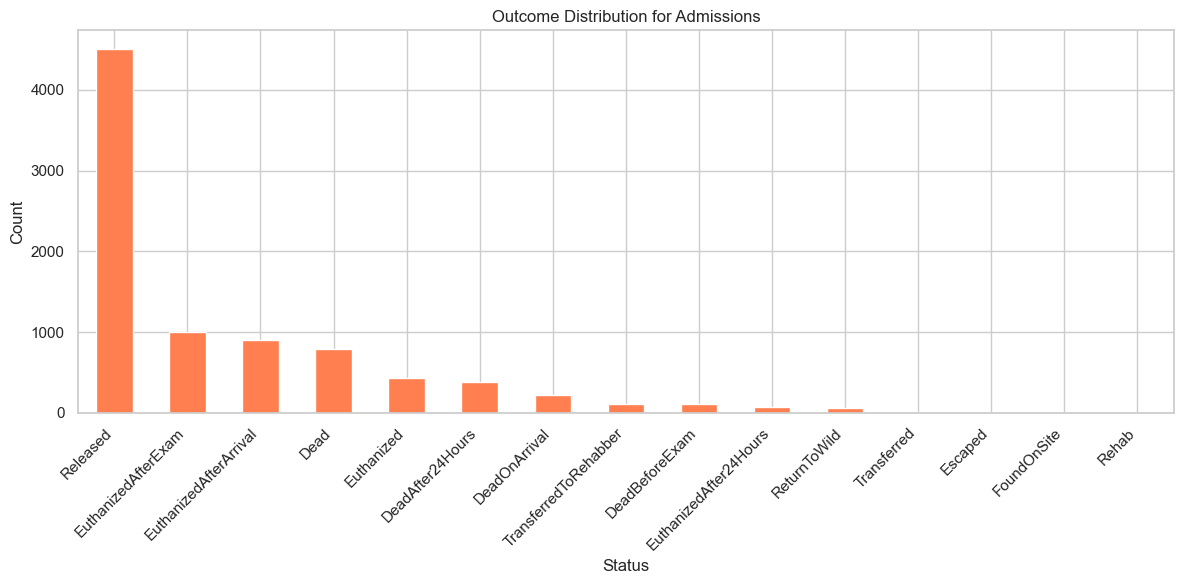

In [18]:
focus_status = focus_df["status"].value_counts()
focus_status.plot(kind="bar", color="coral")
plt.title("Outcome Distribution for Admissions")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()